# Partial Binding: Few-Shot Digit Recognition

All previous notebooks evaluate a logical expression by providing all variable
bindings at once. pysignet also supports *partial binding*: you can fix some
variables in advance and leave others free to be supplied later. This is most
useful when one side of a relation is a stable reference -- something you want
to fix once -- and the other side varies at inference time.

This notebook makes the idea concrete on MNIST. We have a small number of
labeled images per digit class -- the *exemplars* -- and a large unlabeled
pool. We train a learned `Similar(X1, X2)` predicate and then, for each digit
class `i`, compile a single-variable predicate that has the exemplars of that
class baked in:

```python
C_i = compile_logic(ForAll(Y, range(N_EXEMPLARS), Similar(X, Y)), pred_i)
```

The exemplars appear inside `pred_i` as a closure; `X` is the free variable.
Calling `C_i(X=query)` asks: *how consistently does this image resemble all
the exemplars of digit i?* Classification is then `argmax_i C_i(X=query)`.

We also compare `ForAll` against `Exists`, which asks whether the query
resembles *at least one* exemplar. The two correspond to different notions of
nearest-neighbour classification, and the comparison illustrates how the choice
of quantifier shapes the decision rule.

By the end of this notebook, we will have seen:

1. How `ForAll` and `Exists` over a finite domain implement partial binding
2. How symmetry regularisation on unlabeled data improves a learned similarity
3. How `ForAll` and `Exists` relate to different notions of nearest-neighbour

## Preliminaries

The `torchvision` library provides the MNIST dataset and is not part of
pysignet's dependencies.

In [1]:
%pip install torchvision -q -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pysignet as psn

## Data

We load MNIST and select a small number of exemplar images per digit class at
random. Everything else in the training set becomes the unlabeled pool, which
we use only for symmetry regularisation.

In [3]:
N_EXEMPLARS = 5

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1)),
])

train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

def bulk_load(dataset: torch.utils.data.Dataset) -> tuple[torch.Tensor, torch.Tensor]:
    """Load a full dataset into flat tensors for fast random access."""
    xs, ys = [], []
    for x, y in DataLoader(dataset, batch_size=10_000, shuffle=False):
        xs.append(x); ys.append(y)
    return torch.cat(xs), torch.cat(ys)

all_train_x, all_train_y = bulk_load(train_dataset)   # (60000, 784)
test_x,      test_y      = bulk_load(test_dataset)    # (10000, 784)

# Select N_EXEMPLARS per class
torch.manual_seed(0)
exemplar_idx = []
for d in range(10):
    cls_idx = (all_train_y == d).nonzero(as_tuple=True)[0]
    exemplar_idx.append(cls_idx[torch.randperm(len(cls_idx))[:N_EXEMPLARS]])
exemplar_idx = torch.cat(exemplar_idx)

ex_x = all_train_x[exemplar_idx]   # (N_EXEMPLARS * 10, 784)
ex_y = all_train_y[exemplar_idx]
exemplars = {d: ex_x[ex_y == d] for d in range(10)}

# Unlabeled pool: everything except the exemplars, capped at 10k for speed
mask = torch.ones(len(all_train_x), dtype=torch.bool)
mask[exemplar_idx] = False
unlabeled_x = all_train_x[mask][:10_000]

# Supervised pairs: same-class (positive) and cross-class (negative)
pos_x1, pos_x2 = [], []
for d in range(10):
    e = exemplars[d]
    for i in range(len(e)):
        for j in range(i + 1, len(e)):
            pos_x1.append(e[i]); pos_x2.append(e[j])
pos_x1, pos_x2 = torch.stack(pos_x1), torch.stack(pos_x2)

torch.manual_seed(1)
neg_x1, neg_x2 = [], []
while len(neg_x1) < len(pos_x1):
    d1, d2 = torch.randperm(10)[:2].tolist()
    neg_x1.append(exemplars[d1][torch.randint(N_EXEMPLARS, (1,)).item()])
    neg_x2.append(exemplars[d2][torch.randint(N_EXEMPLARS, (1,)).item()])
neg_x1, neg_x2 = torch.stack(neg_x1), torch.stack(neg_x2)

sup_x1 = torch.cat([pos_x1, neg_x1])
sup_x2 = torch.cat([pos_x2, neg_x2])
sup_y  = torch.cat([torch.ones(len(pos_x1)), torch.zeros(len(neg_x1))])
sup_loader = DataLoader(
    TensorDataset(sup_x1, sup_x2, sup_y), batch_size=32, shuffle=True,
    generator=torch.Generator().manual_seed(0),
)

print(f'Exemplars:  {N_EXEMPLARS} per class  ({len(ex_x)} total)')
print(f'Sup pairs:  {len(pos_x1)} positive, {len(neg_x1)} negative')
print(f'Unlabeled:  {len(unlabeled_x)}')
print(f'Test:       {len(test_x)}')

Exemplars:  5 per class  (50 total)
Sup pairs:  100 positive, 100 negative
Unlabeled:  10000
Test:       10000


## The similarity model

`Similar(X1, X2)` is a small MLP that concatenates both images and outputs a
scalar in [0, 1]. Because the inputs are concatenated in order, the model is
asymmetric by construction: `model(A, B)` can differ from `model(B, A)`. This
is deliberate -- it gives the symmetry constraint real work to do.

The `forward` method accepts `x2` as either a batch `(B, 784)` or a single
image `(784,)`. When called with a single image -- as happens when a domain
quantifier substitutes one exemplar at a time -- it broadcasts `x2` to match
the query batch before concatenating. This keeps the predicate definition
simple.

In [4]:
class SimilarityModel(nn.Module):
    def __init__(self, input_dim: int = 784) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim * 2, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x1: torch.Tensor, x2: torch.Tensor) -> torch.Tensor:
        if x2.dim() == 1:
            x2 = x2.unsqueeze(0).expand_as(x1)
        return self.net(torch.cat([x1, x2], dim=-1)).squeeze(-1)

## Training

Training uses two signals.

1. **Supervised pairs** from the exemplar set: Same-class pairs should score high (`Similar(X1, X2)`), and cross-class pairs should score low (`Not(Similar(X1, X2))`).
 2. **Symmetry on Unlabeled pairs**: `Equivalent(Similar(X1, X2), Similar(X2, X1))` on the unlabeled pool regularizes the model top roduce consistent symmetric judgements, encouraging the kind of symmetry that a true distance metric would satisfy.

Both signals use the same predicate registration, so the compiled expressions share model weights automatically.

In [5]:
def train(
    n_epochs: int = 40,
    lr: float = 1e-3,
    sym_weight: float = 0.1,
) -> tuple[nn.Module, list[float]]:
    model = SimilarityModel()

    # 1. Register the model under the predicate name
    predicates = {'Similar': lambda x1, x2: model(x1, x2)}

    X1, X2 = psn.Variable('X1 X2')
    Sim     = psn.Symbol('Similar')

    # 2. Compile three expressions that share the same predicate
    pos_loss = psn.logic_to_loss(Sim(X1, X2),           predicates)
    neg_loss = psn.logic_to_loss(psn.Not(Sim(X1, X2)),  predicates)
    sym_loss = psn.logic_to_loss(
        psn.Equivalent(Sim(X1, X2), Sim(X2, X1)), predicates
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history   = []

    for epoch in range(n_epochs):
        model.train()
        epoch_loss, n_steps = 0.0, 0

        for x1b, x2b, yb in sup_loader:
            optimizer.zero_grad()

            pos_mask = yb == 1
            neg_mask = yb == 0

            # 3. Supervised loss on labeled exemplar pairs
            sup = (
                pos_loss.loss(X1=x1b[pos_mask], X2=x2b[pos_mask],
                              quantify='none', reduction='mean')
                + neg_loss.loss(X1=x1b[neg_mask], X2=x2b[neg_mask],
                                quantify='none', reduction='mean')
            )

            # 4. Symmetry loss on a random unlabeled pair
            idx = torch.randperm(len(unlabeled_x))[:64]
            sym = sym_loss.loss(
                X1=unlabeled_x[idx[:32]], X2=unlabeled_x[idx[32:]],
                quantify='none', reduction='mean',
            )

            (sup + sym_weight * sym).backward()
            optimizer.step()
            epoch_loss += sup.item() + sym_weight * sym.item()
            n_steps    += 1

        history.append(epoch_loss / n_steps)
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1:2d}/{n_epochs}  loss = {history[-1]:.4f}')

    return model, history


torch.manual_seed(42)
model, history = train()

Epoch 10/40  loss = 0.2555


Epoch 20/40  loss = 0.0462


Epoch 30/40  loss = 0.0198


Epoch 40/40  loss = 0.0085


## Per-digit classifiers

Now we can build the per-digit classifiers. For each digit `i`, we compile a
single-variable predicate that has the exemplars of that class baked in via a
predicate closure.

When pysignet evaluates `ForAll(Y, range(N_EXEMPLARS), Similar(X, Y))`, it
substitutes each domain value in turn as a constant argument to the predicate.
The predicate closure looks up `exs[y_idx]` to retrieve the corresponding
exemplar image and passes it to the model alongside the query batch `x`. Because
`SimilarityModel.forward` broadcasts a single image to match the batch
dimension, no reshape logic is needed in the predicate itself.

We compile two variants. With `MixedTNorm` and five exemplars (arity 5 > 4),
both reduce to Godel operators:

- **`ForAll`** reduces to the minimum similarity over exemplars. The query must
  resemble the hardest exemplar to score well.
- **`Exists`** reduces to the maximum similarity. It is enough to resemble the
  closest exemplar -- equivalent to 1-nearest-neighbour.

In [6]:
def make_classifiers(model: nn.Module, mode: str = 'forall') -> list:
    """Compile one per-digit classifier with exemplars captured in a closure."""
    X, Y      = psn.Variable('X Y')
    Sim       = psn.Symbol('Similar')
    quantifier = psn.ForAll if mode == 'forall' else psn.Exists

    def make_pred(exs: torch.Tensor) -> dict:
        return {'Similar': lambda x, y_idx: model(x, exs[int(y_idx)])}

    return [
        psn.compile_logic(
            quantifier(Y, range(N_EXEMPLARS), Sim(X, Y)),
            make_pred(exemplars[d]),
        )
        for d in range(10)
    ]

## ForAll vs Exists

We apply both sets of classifiers to the full test set. For each query image
we collect the ten scores, one per digit class, and predict the class with the
highest score.

In [7]:
def classify(classifiers: list, x: torch.Tensor, batch_size: int = 512) -> torch.Tensor:
    """Score every query against all ten per-digit classifiers and argmax."""
    preds = []
    for start in range(0, len(x), batch_size):
        xb     = x[start : start + batch_size]
        scores = torch.stack([C(X=xb) for C in classifiers], dim=1)  # (B, 10)
        preds.append(scores.argmax(dim=1))
    return torch.cat(preds)


model.eval()
with torch.no_grad():
    c_fa     = make_classifiers(model, 'forall')
    c_ex     = make_classifiers(model, 'exists')
    preds_fa = classify(c_fa, test_x)
    preds_ex = classify(c_ex, test_x)

acc_fa = (preds_fa == test_y).float().mean().item()
acc_ex = (preds_ex == test_y).float().mean().item()
print(f'ForAll accuracy: {acc_fa:.4f}')
print(f'Exists accuracy: {acc_ex:.4f}')

ForAll accuracy: 0.4088
Exists accuracy: 0.3096


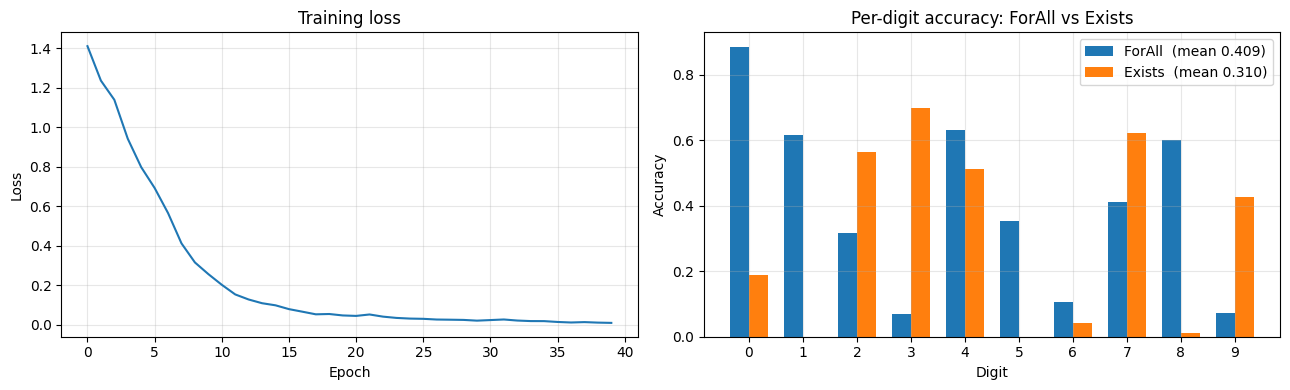

In [8]:
per_class_fa = [(preds_fa[test_y == d] == d).float().mean().item() for d in range(10)]
per_class_ex = [(preds_ex[test_y == d] == d).float().mean().item() for d in range(10)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training loss')
ax1.grid(True, alpha=0.3)

x = np.arange(10)
w = 0.35
ax2.bar(x - w / 2, per_class_fa, w, label=f'ForAll  (mean {acc_fa:.3f})')
ax2.bar(x + w / 2, per_class_ex, w, label=f'Exists  (mean {acc_ex:.3f})')
ax2.set_xlabel('Digit')
ax2.set_ylabel('Accuracy')
ax2.set_title('Per-digit accuracy: ForAll vs Exists')
ax2.set_xticks(x)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion

### ForAll and Exists as k-NN variants

With MixedTNorm and five exemplars the two quantifiers reduce to Godel operators. There is a natural k-nearest neighbors analogy.

- **Exists** is 1-NN: assign the class whose nearest exemplar has the highest
  similarity score.
- **ForAll** is a max-margin rule: a class scores well only if the query clears
  even its hardest exemplar. A single atypical exemplar can suppress an
  otherwise strong class score.
- Standard k-NN with majority voting sits between the two: it counts how many
  of the k exemplars agree, corresponding to neither a pure min nor a pure max.

### Role of symmetry

The model concatenates inputs in order, so `model(A, B)`
and `model(B, A)` are in general different. Without the symmetry constraint, the
score `C_i(X=query)` can depend on the direction of comparison between the query
and each exemplar. The constraint
`Equivalent(Similar(X1, X2), Similar(X2, X1))` on the unlabeled pool removes
this directional bias.

### Partial binding

Each `C_i` is a self-contained, single-variable predicate.
It can be stored in a list, passed to any function, or called on batches of
any size without re-specifying the exemplars. The per-digit structure of the
inference loop emerges naturally from the compilation step, not from hand-written
indexing logic.